In [1]:

import os
import scipy.io
import h5py
import numpy as np
import sys
from scipy import signal as sig
from scipy import stats as stats
import math
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy import signal
import seaborn as sns
import logging

%matplotlib widget

scripts_path = '/home/apollo/Documents/github_projects/ripple_sync/scripts/hc_18_scripts/'
data_path = "/media/apollo/projects/hc-18/data/"

os.chdir(scripts_path)

import hc18_BaseFunctions as hc18_bf
import ripple_detection as ripple
import normalizing_functions as norm
import helper_functions as helper
import bootstrapped_estimation as bootstrap



scripts_path = '/home/apollo/Documents/github_projects/ripple_sync/scripts/hc_11_scripts/'
os.chdir(scripts_path)

import hc11_BaseFunctions as hc11_bf

sessions = ['Achilles_10252013','Buddy_06272013','Cicero_09012014','Gatsby_08022013','Achilles_11012013','Cicero_09102014','Cicero_09172014','Gatsby_08282013']

rejected_shanks = np.load('rejected_shanks.npy',allow_pickle=True).item()
rejected_electrodes = np.load('rejected_electrodes.npy',allow_pickle=True).item()


In [2]:

# set the font globally
plt.rcParams.update({'font.family':'sans-serif'})
# set the font name for a font family
plt.rcParams.update({'font.sans-serif':'Arial'})
# when saving svg, keep text as text
plt.rcParams['svg.fonttype'] = 'none' 


In [2]:

output_dict = dict()
output_dict['rat'] = []
output_dict['session'] = []
output_dict['side'] = []
output_dict['state'] = []
output_dict['shank_1'] = []
output_dict['shank_2'] = []
output_dict['shanks_distance'] = []
output_dict['phase_phase_coupling'] = []
output_dict['phase_phase_direction'] = []

srate = 1250.
ripple_threshold_level = 2
ripple_low_freq = 100
ripple_high_freq = 250
minimum_ripple_length = 0.03*srate
smooth_points = 0.001*srate

states = ['pre','post']
for session in sessions:

    print(session)
    # logging.info('session = ' + str(session))
    
    all_shanks,left_shanks,right_shanks = hc11_bf.get_shanks_info(session)
    LFP,srate,SWS,SWS_lfp_index,SWS_lfp_index_pre,SWS_lfp_index_pos = hc11_bf.load_lfp_hc11_data(session)
    # spike_times,spike_ids,pyr_ids,int_ids = hc11_bf.load_spikes_hc11_data(RatName)
        
    os.chdir(scripts_path)
    all_shanks_electrode_position = np.load(f'electrode_position_{session}.npy')

    all_shanks_distance_to_ref = np.arange(0,(len(all_shanks)/2)*200,200)
    all_shanks_distance_to_ref = np.concatenate([all_shanks_distance_to_ref,all_shanks_distance_to_ref])
    accepted_shanks = np.setdiff1d(np.arange(len(all_shanks)),rejected_shanks[session])

    for state in states:
        
        if state == 'pre':
            # lfp_index = SWS_lfp_index_pre[-int(30*60*srate):]
            lfp_index = SWS_lfp_index_pre[0:int(30*60*srate)]
            
        elif state == 'post':
            lfp_index = SWS_lfp_index_pos[0:int(30*60*srate)]
                
        # for shank_1_idx in [0]:
        for shank_1_idx in np.arange(0,len(accepted_shanks)-1):    
            
            shank_1 = accepted_shanks[shank_1_idx]
            print('Shank 1 = ' + str(shank_1))
    
            Imaxripple = np.where(all_shanks_electrode_position[shank_1]==0)[0][0]
            shanks = all_shanks[shank_1]
            ripple_lfp_1 = LFP[shanks[Imaxripple],lfp_index].copy()
    
            ripple_filtered_1 = sig.detrend(hc11_bf.eegfilt(ripple_lfp_1,srate,100,250))
            ripple_hilbert_1 = hc11_bf.hilbert(ripple_filtered_1)
            ripple_phase_1 = np.angle(ripple_hilbert_1)
            # ripple_amp_1 = np.abs(ripple_hilbert_1)
    
            # for shank_2_idx in [1,9]:
            for shank_2_idx in np.arange(shank_1_idx+1,len(accepted_shanks)):
                shank_2 = accepted_shanks[shank_2_idx]
                # print('Shank 2 = ' + str(shank_2))
                
                shanks_distance = np.abs((all_shanks_distance_to_ref[shank_1] - all_shanks_distance_to_ref[shank_2]))
                if shanks_distance > 1200:
                    continue
    
                Imaxripple = np.where(all_shanks_electrode_position[shank_2]==0)[0][0]
                shanks = all_shanks[shank_2]
                ripple_lfp_2 = LFP[shanks[Imaxripple],lfp_index].copy()
    
                ripple_filtered_2 = sig.detrend(hc11_bf.eegfilt(ripple_lfp_2,srate,100,250))
                ripple_hilbert_2 = hc11_bf.hilbert(ripple_filtered_2)
                ripple_phase_2 = np.angle(ripple_hilbert_2)
                # ripple_amp_2 = np.abs(ripple_hilbert_2)
    
                ripple_phase_diff = np.exp(1j*(np.unwrap(ripple_phase_1)-np.unwrap(ripple_phase_2)))
    
                phasediff_r = np.abs(np.nanmean(ripple_phase_diff))
                mean_phasediff = np.angle(np.nanmean(ripple_phase_diff))
    
                if ((shank_1 in left_shanks) & (shank_2 in left_shanks)) | ((shank_1 in right_shanks) & (shank_2 in right_shanks)):
                    side = 'ipsi'
                else:
                    side = 'contra'
                

                
                output_dict['rat'].append(session[0:3])
                output_dict['session'].append(session)
                output_dict['side'].append(side)
                output_dict['state'].append(state)
                output_dict['shank_1'].append(shank_1)
                output_dict['shank_2'].append(shank_2)
                output_dict['shanks_distance'].append(shanks_distance)
                output_dict['phase_phase_coupling'].append(phasediff_r)
                output_dict['phase_phase_direction'].append(mean_phasediff)
                

df = pd.DataFrame(output_dict)
df

path = "/home/apollo/Documents/github_projects/ripple_sync/results/"
os.chdir(path)

df.to_csv('Figure_Ripple_PhasePhaseCoupling_WholeSignal_PrePost.csv',index=False)


Achilles_10252013
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 7
Shank 1 = 8
Shank 1 = 9
Shank 1 = 10
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 7
Shank 1 = 8
Shank 1 = 9
Shank 1 = 10
Buddy_06272013
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 9
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 9
Cicero_09012014
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 7
Shank 1 = 8
Shank 1 = 9
Shank 1 = 10
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 7
Shank 1 = 8
Shank 1 = 9
Shank 1 = 10
Gatsby_08022013
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 11
Shank 1 = 12
Shank 1 = 13
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shan

,rat,session,side,state,shank_1,shank_2,shanks_distance,phase_phase_coupling,phase_phase_direction
0,Ach,Achilles_10252013,ipsi,pre,0,1,200.0,0.707070,-0.048654
1,Ach,Achilles_10252013,ipsi,pre,0,2,400.0,0.600341,-0.111149
2,Ach,Achilles_10252013,ipsi,pre,0,3,600.0,0.493339,-0.169445
3,Ach,Achilles_10252013,ipsi,pre,0,4,800.0,0.427793,-0.233492
4,Ach,Achilles_10252013,ipsi,pre,0,5,1000.0,0.353960,-0.361739
...,...,...,...,...,...,...,...,...,...
925,Gat,Gatsby_08282013,ipsi,post,12,14,400.0,0.686969,0.106185
926,Gat,Gatsby_08282013,ipsi,post,12,15,600.0,0.552821,0.247093
927,Gat,Gatsby_08282013,ipsi,post,13,14,200.0,0.717975,0.093197
928,Gat,Gatsby_08282013,ipsi,post,13,15,400.0,0.567318,0.245405


In [3]:
path = "/home/apollo/Documents/github_projects/ripple_sync/results/"
os.chdir(path)

filename = 'Figure_Ripple_PhasePhaseCoupling_WholeSignal_PrePost.csv'
df = pd.read_csv(filename)

# Set reference categories
# df['side'] = pd.Categorical(df['side'], categories=['ipsi', 'contra'], ordered=True)
# df['state'] = pd.Categorical(df['state'], categories=['pre', 'post'], ordered=True)
df


,rat,session,side,state,shank_1,shank_2,shanks_distance,phase_phase_coupling,phase_phase_direction
0,Ach,Achilles_10252013,ipsi,pre,0,1,200.0,0.707070,-0.048654
1,Ach,Achilles_10252013,ipsi,pre,0,2,400.0,0.600341,-0.111149
2,Ach,Achilles_10252013,ipsi,pre,0,3,600.0,0.493339,-0.169445
3,Ach,Achilles_10252013,ipsi,pre,0,4,800.0,0.427793,-0.233492
4,Ach,Achilles_10252013,ipsi,pre,0,5,1000.0,0.353960,-0.361739
...,...,...,...,...,...,...,...,...,...
925,Gat,Gatsby_08282013,ipsi,post,12,14,400.0,0.686969,0.106185
926,Gat,Gatsby_08282013,ipsi,post,12,15,600.0,0.552821,0.247093
927,Gat,Gatsby_08282013,ipsi,post,13,14,200.0,0.717975,0.093197
928,Gat,Gatsby_08282013,ipsi,post,13,15,400.0,0.567318,0.245405


In [5]:
np.sum(df['side'] == 'ipsi')/2

np.float64(220.0)

In [6]:
np.sum(df['side'] == 'contra')/2

np.float64(245.0)

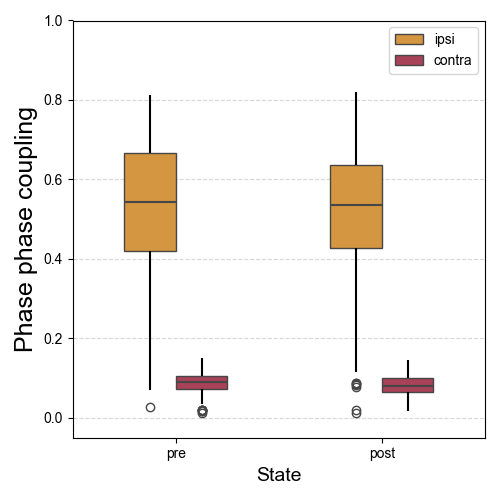

In [4]:

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

# sns.stripplot(data=df, x="state", order = ['pre','post'], y="phase_phase_coupling", hue='side',
#               hue_order=["ipsi", "contra"], palette=my_pal,size=6,alpha=1)

box = sns.boxplot(data=df, x="state",order = ['pre','post'], y="phase_phase_coupling", hue='side',
            hue_order=['ipsi','contra'], showfliers=True, showcaps=False,palette=my_pal,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5)  # Using the custom color palette

# ax=sns.violinplot(data=df,x="state", order = ['pre','post'], y="phase_phase_coupling", hue='side',
#                 hue_order=["ipsi", "contra"], palette=my_pal,fill=True,inner = None,\
#                 split=True, density_norm='width',saturation=1,bw_adjust=0.5,native_scale=True)
# plt.setp(ax.collections, alpha=.3)

plt.ylabel('Phase phase coupling',fontsize=18)
plt.xlabel('State',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
# plt.legend([], [], frameon=False)
plt.ylim([-0.05,1])
plt.legend()
# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
# plt.xticks([0,1],labels=['Left','Right'])
plt.tight_layout()


os.chdir(scripts_path + '/figures/')
fig_name = 'Figure_Ripple_PhasePhase_PrePost.svg'
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# helper.delete_clip_path(fig_name)



In [5]:

import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "phase_phase_coupling ~ C(side, Treatment(reference='ipsi')) * C(state, Treatment(reference='pre'))"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())


                                                 Mixed Linear Model Regression Results
Model:                                   MixedLM                        Dependent Variable:                        phase_phase_coupling
No. Observations:                        930                            Method:                                    REML                
No. Groups:                              4                              Scale:                                     0.0117              
Min. group size:                         72                             Log-Likelihood:                            724.2614            
Max. group size:                         396                            Converged:                                 Yes                 
Mean group size:                         232.5                                                                                         
-------------------------------------------------------------------------------------------------

/home/apollo/.pyenv/versions/3.13.5/envs/ripple_sync/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apollo/.pyenv/versions/3.13.5/envs/ripple_sync/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/apollo/.pyenv/versions/3.13.5/envs/ripple_sync/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/apollo/.pyenv/versions/3.13.5/envs/ripple_sync/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


Intercept                                                                                      3.521668e-71
C(side, Treatment(reference='ipsi'))[T.contra]                                                 0.000000e+00
C(state, Treatment(reference='pre'))[T.post]                                                   3.484402e-01
C(side, Treatment(reference='ipsi'))[T.contra]:C(state, Treatment(reference='pre'))[T.post]    7.970528e-01
rat Var                                                                                                 NaN
session Var                                                                                    3.640312e-01
dtype: float64

In [10]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df['group'] = df['side'].astype(str) + "_" + df['state'].astype(str)

# Tukey HSD
tukey = pairwise_tukeyhsd(endog=df['phase_phase_coupling'],
                          groups=df['group'],
                          alpha=0.05)
print(tukey)


    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
   group1     group2   meandiff p-adj   lower  upper  reject
------------------------------------------------------------
contra_post contra_pre    0.006 0.9356 -0.0203 0.0323  False
contra_post  ipsi_post   0.4383    0.0  0.4112 0.4653   True
contra_post   ipsi_pre   0.4479    0.0  0.4209  0.475   True
 contra_pre  ipsi_post   0.4323    0.0  0.4052 0.4593   True
 contra_pre   ipsi_pre   0.4419    0.0  0.4149 0.4689   True
  ipsi_post   ipsi_pre   0.0097 0.8068 -0.0181 0.0374  False
------------------------------------------------------------


In [ ]:

diff_counts = -1*np.squeeze(np.diff(mean_r_value,axis=0))
diff_counts


mean_diff = np.nanmean(diff_counts, axis=0)
std_diff = np.nanstd(diff_counts, axis=0)
ci_lower,ci_upper = confidence_interval(diff_counts,confidence=0.95)
errors_ = (ci_upper - ci_lower) / 2
ci_lower,ci_upper

In [15]:
df

,rat,session,side,state,shank_1,shank_2,shanks_distance,phase_phase_coupling,phase_phase_direction
0,Ach,Achilles_10252013,ipsi,pre,0,1,200.0,0.707070,-0.048654
1,Ach,Achilles_10252013,ipsi,pre,0,2,400.0,0.600341,-0.111149
2,Ach,Achilles_10252013,ipsi,pre,0,3,600.0,0.493339,-0.169445
3,Ach,Achilles_10252013,ipsi,pre,0,4,800.0,0.427793,-0.233492
4,Ach,Achilles_10252013,ipsi,pre,0,5,1000.0,0.353960,-0.361739
...,...,...,...,...,...,...,...,...,...
925,Gat,Gatsby_08282013,ipsi,post,12,14,400.0,0.686969,0.106185
926,Gat,Gatsby_08282013,ipsi,post,12,15,600.0,0.552821,0.247093
927,Gat,Gatsby_08282013,ipsi,post,13,14,200.0,0.717975,0.093197
928,Gat,Gatsby_08282013,ipsi,post,13,15,400.0,0.567318,0.245405


In [4]:
sides = ['ipsi','contra']
states = ['pre','post']

mean_phase_phase_coupling = []
for session in sessions:
    df_session = df['session'] == session

    state_aux = []
    for state in states:
        df_state = df['state'] == state

        side_aux = []
        for side in sides:
            df_side = df['side'] == side
            side_aux.append(np.nanmean(df['phase_phase_coupling'][df_session*df_side*df_state].values))
        state_aux.append(side_aux)
    mean_phase_phase_coupling.append(state_aux)
    
mean_phase_phase_coupling = np.array(mean_phase_phase_coupling)
mean_phase_phase_coupling.shape


(8, 2, 2)

In [ ]:
# mean_phase_phase_coupling[session,state,side]


In [5]:
# pre
mean_phase_phase_coupling[:,0,:]
# post
mean_phase_phase_coupling[:,1,:]


array([[0.58878352, 0.10853953],
       [0.50781928, 0.04992618],
       [0.5111769 , 0.074816  ],
       [0.48340148, 0.10261996],
       [0.57808118, 0.10200235],
       [0.53036511, 0.06826362],
       [0.54839453, 0.06984198],
       [0.35844539, 0.05522491]])

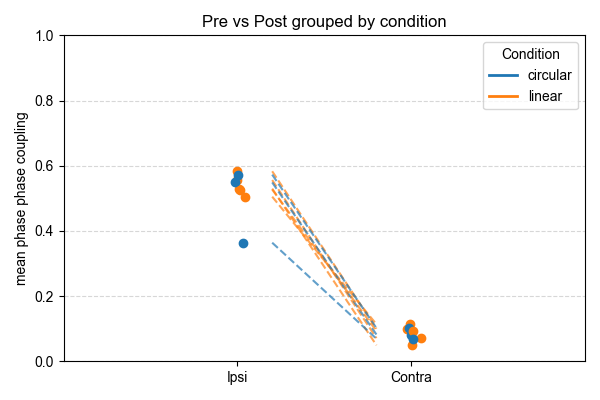

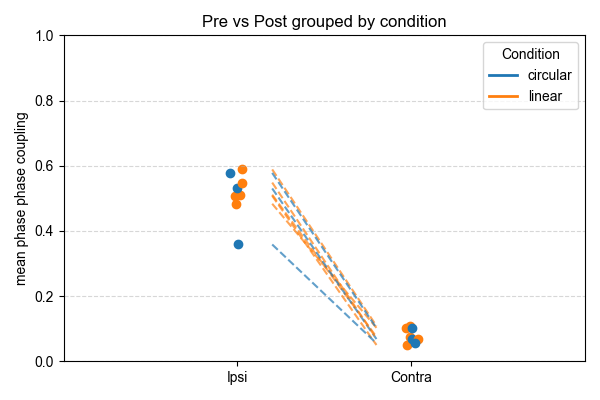

In [6]:
labels = np.array(['linear','linear','linear','linear','circular','circular','linear','circular'])

# Step 1: assign unique colors to each label
unique_labels = np.unique(labels)
cmap = plt.get_cmap('tab10')  # categorical colormap
color_map = {lab: cmap(i) for i, lab in enumerate(unique_labels)}

for state in [0,1]:
    phase_phase_coupling = mean_phase_phase_coupling[:,state,:].T.copy()
    # Step 2: plot
    plt.figure(figsize=(6, 4))
    x_coords = [0.2, 0.8]
    
    for i in range(phase_phase_coupling.shape[1]):
        lab = labels[i]
        color = color_map[lab]
        # Line between paired points
        plt.plot(x_coords, phase_phase_coupling[:, i], color=color, linestyle='--', alpha=0.7)
        # Plot dots
        jitter_strength = 0.02  # Adjust the strength of jitter
        x_values = np.random.randn(1) * jitter_strength
        plt.scatter(0+x_values, phase_phase_coupling[0, i], color=color, edgecolor=color)
        
        jitter_strength = 0.02  # Adjust the strength of jitter
        x_values = np.random.randn(1) * jitter_strength
        plt.scatter(1+x_values, phase_phase_coupling[1, i], color=color, edgecolor=color)
    
    # Step 3: legend for labels
    handles = [plt.Line2D([0], [0], color=color_map[lab], lw=2) for lab in unique_labels]
    plt.legend(handles, unique_labels, title='Condition', bbox_to_anchor=(1, 1))
    plt.grid(linestyle='--',alpha=0.5,axis='y')
    
    # Aesthetic touches
    plt.xticks([0, 1], ['Ipsi', 'Contra'])
    plt.xlim([-1, 2])
    plt.ylim([0, 1])
    plt.ylabel('mean phase phase coupling')
    plt.title('Pre vs Post grouped by condition')
    plt.tight_layout()
    
    os.chdir(scripts_path + '/figures/')
    fig_name = f'Figure_Ripple_PhasePhase_{state}_Average.svg'
    
    # plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
    plt.show()
    # helper.delete_clip_path(fig_name)



In [7]:
df

,rat,session,side,state,shank_1,shank_2,shanks_distance,phase_phase_coupling,phase_phase_direction
0,Ach,Achilles_10252013,ipsi,pre,0,1,200.0,0.707070,-0.048654
1,Ach,Achilles_10252013,ipsi,pre,0,2,400.0,0.600341,-0.111149
2,Ach,Achilles_10252013,ipsi,pre,0,3,600.0,0.493339,-0.169445
3,Ach,Achilles_10252013,ipsi,pre,0,4,800.0,0.427793,-0.233492
4,Ach,Achilles_10252013,ipsi,pre,0,5,1000.0,0.353960,-0.361739
...,...,...,...,...,...,...,...,...,...
925,Gat,Gatsby_08282013,ipsi,post,12,14,400.0,0.686969,0.106185
926,Gat,Gatsby_08282013,ipsi,post,12,15,600.0,0.552821,0.247093
927,Gat,Gatsby_08282013,ipsi,post,13,14,200.0,0.717975,0.093197
928,Gat,Gatsby_08282013,ipsi,post,13,15,400.0,0.567318,0.245405


In [5]:
df_long = (
    df.groupby(['session', 'state', 'side'], as_index=False)['phase_phase_coupling']
      .mean()
      .rename(columns={'phase_phase_coupling': 'mean_phase_phase_coupling'})
)

df_long


,session,state,side,mean_phase_phase_coupling
0,Achilles_10252013,post,contra,0.108540
1,Achilles_10252013,post,ipsi,0.588784
2,Achilles_10252013,pre,contra,0.099928
3,Achilles_10252013,pre,ipsi,0.583086
4,Achilles_11012013,post,contra,0.102002
5,Achilles_11012013,post,ipsi,0.578081
6,Achilles_11012013,pre,contra,0.101652
7,Achilles_11012013,pre,ipsi,0.572825
8,Buddy_06272013,post,contra,0.049926
9,Buddy_06272013,post,ipsi,0.507819


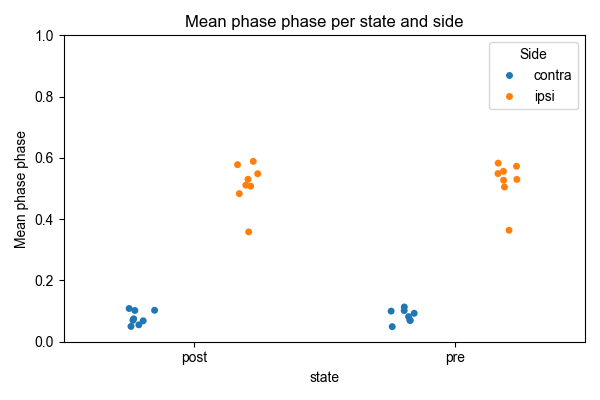

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you already have mean_r_value_df_long
plt.figure(figsize=(6, 4))
sns.stripplot(
    data=df_long,
    x='state',
    y='mean_phase_phase_coupling',
    hue='side',
    dodge=True,
    jitter=True
)

plt.ylabel("Mean phase phase")
plt.title("Mean phase phase per state and side")
plt.legend(title="Side")
plt.ylim([0,1])
plt.tight_layout()
plt.show()


In [6]:

# Ensure 'side' and 'state' are treated as strings
df_long['side'] = df_long['side'].astype(str)
df_long['state'] = df_long['state'].astype(str)

# Create a 'grp' column for combinations of 'side' and 'state'
df_long['grp'] = df_long['side'] + '_' + df_long['state']

# Display the resulting DataFrame
print(df_long)

              session state    side  mean_phase_phase_coupling          grp
0   Achilles_10252013  post  contra                   0.108540  contra_post
1   Achilles_10252013  post    ipsi                   0.588784    ipsi_post
2   Achilles_10252013   pre  contra                   0.099928   contra_pre
3   Achilles_10252013   pre    ipsi                   0.583086     ipsi_pre
4   Achilles_11012013  post  contra                   0.102002  contra_post
5   Achilles_11012013  post    ipsi                   0.578081    ipsi_post
6   Achilles_11012013   pre  contra                   0.101652   contra_pre
7   Achilles_11012013   pre    ipsi                   0.572825     ipsi_pre
8      Buddy_06272013  post  contra                   0.049926  contra_post
9      Buddy_06272013  post    ipsi                   0.507819    ipsi_post
10     Buddy_06272013   pre  contra                   0.049187   contra_pre
11     Buddy_06272013   pre    ipsi                   0.529887     ipsi_pre
12    Cicero

In [7]:
df_pivot = df_long.pivot(index='session', columns='grp', values='mean_phase_phase_coupling')
df_pivot

grp,contra_post,contra_pre,ipsi_post,ipsi_pre
session,,,,
Achilles_10252013,0.108540,0.099928,0.588784,0.583086
Achilles_11012013,0.102002,0.101652,0.578081,0.572825
Buddy_06272013,0.049926,0.049187,0.507819,0.529887
Cicero_09012014,0.074816,0.070915,0.511177,0.556234
Cicero_09102014,0.068264,0.081958,0.530365,0.548907
Cicero_09172014,0.069842,0.092876,0.548395,0.527065
Gatsby_08022013,0.102620,0.113459,0.483401,0.505127
Gatsby_08282013,0.055225,0.069169,0.358445,0.363896


In [8]:
# Perform paired t-tests
p_values = {}
for col1 in df_pivot.columns:
    for col2 in df_pivot.columns:
        if col1 != col2 and (col2, col1) not in p_values:
            t_stat, p_val = stats.ttest_rel(df_pivot[col1], df_pivot[col2])
            p_values[(col1, col2)] = p_val

# Display p-values
p_values_df = pd.DataFrame(list(p_values.items()), columns=['Comparison', 'p-value'])
print(p_values_df)

from statsmodels.stats.multitest import multipletests

# Extract p-values from the previous step
pvals = p_values_df['p-value'].values

# Apply Benjamini-Hochberg correction
rejected, pvals_corrected, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')

# Add corrected p-values to the dataframe
p_values_df['p-value (corrected)'] = pvals_corrected
p_values_df['Reject H0'] = rejected

print(p_values_df)


                  Comparison       p-value
0  (contra_post, contra_pre)  1.644667e-01
1   (contra_post, ipsi_post)  2.159787e-07
2    (contra_post, ipsi_pre)  1.558132e-07
3    (contra_pre, ipsi_post)  3.697997e-07
4     (contra_pre, ipsi_pre)  3.083134e-07
5      (ipsi_post, ipsi_pre)  2.157574e-01
                  Comparison       p-value  p-value (corrected)  Reject H0
0  (contra_post, contra_pre)  1.644667e-01         1.973601e-01      False
1   (contra_post, ipsi_post)  2.159787e-07         5.546996e-07       True
2    (contra_post, ipsi_pre)  1.558132e-07         5.546996e-07       True
3    (contra_pre, ipsi_post)  3.697997e-07         5.546996e-07       True
4     (contra_pre, ipsi_pre)  3.083134e-07         5.546996e-07       True
5      (ipsi_post, ipsi_pre)  2.157574e-01         2.157574e-01      False


In [13]:
import pingouin as pg
import pandas as pd

# Assuming your df is already loaded
# Make sure the factors are categorical
df_long['state'] = df_long['state'].astype('category')
df_long['side'] = df_long['side'].astype('category')
df_long['session'] = df_long['session'].astype('category')

# Two-way repeated measures ANOVA
aov = pg.rm_anova(
    dv='mean_phase_phase_coupling',
    within=['state', 'side'],
    subject='session',
    data=df_long,
    detailed=True
)
print(aov)

# Post-hoc pairwise comparisons
posthocs = pg.pairwise_tests(
    dv='mean_phase_phase_coupling',
    within=['state', 'side'],
    subject='session',
    padjust='bonf',
    data=df_long,
    effsize='hedges'
)
print(posthocs)


         Source        SS  ddof1  ddof2        MS           F         p-unc  \
0         state  0.000516      1      7  0.000516    5.156320  5.741369e-02   
1          side  1.523872      1      7  1.523872  384.944714  2.231144e-07   
2  state * side  0.000033      1      7  0.000033    0.186615  6.787436e-01   

      p-GG-corr       ng2  eps  
0  5.741369e-02  0.006689  1.0  
1  2.231144e-07  0.952145  1.0  
2  6.787436e-01  0.000435  1.0  
       Contrast state       A     B Paired Parametric          T  dof  \
0         state     -    post   pre   True       True  -2.270753  7.0   
1          side     -  contra  ipsi   True       True -19.620008  7.0   
2  state * side  post  contra  ipsi   True       True -19.712796  7.0   
3  state * side   pre  contra  ipsi   True       True -18.719459  7.0   

  alternative         p-unc        p-corr p-adjust       BF10    hedges  
0   two-sided  5.741369e-02           NaN      NaN      1.713 -0.184059  
1   two-sided  2.231144e-07          

/home/apollo/.pyenv/versions/3.13.5/envs/ripple_sync/lib/python3.13/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/home/apollo/.pyenv/versions/3.13.5/envs/ripple_sync/lib/python3.13/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


In [14]:
posthocs

,Contrast,state,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,state,-,post,pre,True,True,-2.270753,7.0,two-sided,5.741369e-02,NaN,NaN,1.713,-0.184059
1,side,-,contra,ipsi,True,True,-19.620008,7.0,two-sided,2.231144e-07,NaN,NaN,4.73e+04,-7.992141
2,state * side,post,contra,ipsi,True,True,-19.712796,7.0,two-sided,2.159787e-07,4.319574e-07,bonf,4.862e+04,-7.692102
3,state * side,pre,contra,ipsi,True,True,-18.719459,7.0,two-sided,3.083134e-07,6.166268e-07,bonf,3.591e+04,-8.099534


In [15]:
import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "mean_phase_phase_coupling ~ C(side, Treatment(reference='ipsi')) * C(state, Treatment(reference='pre'))"
re_formula = "1"
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, data=df_long,groups='session')
result = model.fit()

# Print summary of the model
print(result.summary())


                                                 Mixed Linear Model Regression Results
Model:                                  MixedLM                      Dependent Variable:                      mean_phase_phase_coupling
No. Observations:                       32                           Method:                                  REML                     
No. Groups:                             8                            Scale:                                   0.0014                   
Min. group size:                        4                            Log-Likelihood:                          42.5342                  
Max. group size:                        4                            Converged:                               Yes                      
Mean group size:                        4.0                                                                                            
-------------------------------------------------------------------------------------------------

/home/apollo/.pyenv/versions/3.13.5/envs/ripple_sync/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [21]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df_long['grp'] = df_long['side'].astype(str) + '_' + df_long['state'].astype(str)

tukey = pairwise_tukeyhsd(
    endog=df_long['mean_phase_phase_coupling'],
    groups=df_long['grp'],
    alpha=0.05
)
print(tukey.summary())


    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
   group1     group2   meandiff p-adj   lower  upper  reject
------------------------------------------------------------
contra_post contra_pre    0.006 0.9957 -0.0654 0.0774  False
contra_post  ipsi_post   0.4344    0.0   0.363 0.5058   True
contra_post   ipsi_pre   0.4445    0.0  0.3731 0.5159   True
 contra_pre  ipsi_post   0.4284    0.0   0.357 0.4998   True
 contra_pre   ipsi_pre   0.4385    0.0  0.3671 0.5099   True
  ipsi_post   ipsi_pre   0.0101 0.9802 -0.0613 0.0815  False
------------------------------------------------------------
